# NASA Asteroid Sınıflandırma Projesi
## Notebook 02 — Baseline Modeller & SHAP Analizi

**Bu notebook'ta yapacaklarımız:**
1. Notebook 01'den kaydedilen veriyi yükle
2. 5 farklı baseline model eğit:
   - Logistic Regression (yorumlanabilir baseline)
   - Random Forest (güçlü ensemble)
   - XGBoost (genellikle en iyi performans)
   - Support Vector Machine
   - K-Nearest Neighbors
3. Her modeli doğru metriklerle değerlendir (Accuracy tek başına YETERSİZ!)
4. Confusion Matrix görselleştirme
5. ROC-AUC ve PR-AUC eğrileri
6. SHAP analizi ile model yorumlama
7. Tüm modellerin karşılaştırma tablosu

> **⚠️ Kritik Hatırlatma:** Sınıf dengesizliği %9.7 PHA. Accuracy'ye değil,
> **Recall** ve **F1-Score** (minority class) metriklerine odaklan!

---
*Önceki adım:* `01_eda_and_cleaning.ipynb`  
*Sonraki adım:* `03_spice_visualization.ipynb`

## 1. Kurulum & Import

In [1]:
!pip install shap xgboost lightgbm -q
print('✅ Kütüphaneler hazır!')

✅ Kütüphaneler hazır!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn — Modeller
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

# Scikit-learn — Değerlendirme
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

# SHAP
import shap

# Görsel ayarlar
plt.style.use('dark_background')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.4f}'.format)

# Tekrar üretilebilirlik
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ Import tamamlandı!')

✅ Import tamamlandı!


## 2. Notebook 01'den Veriyi Yükle

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/nasa_asteroid/'

# Notebook 01'de kaydedilen temizlenmiş veriyi yükle
X_train = pd.read_csv(DRIVE_PATH + 'X_train.csv')
X_test  = pd.read_csv(DRIVE_PATH + 'X_test.csv')
y_train = pd.read_csv(DRIVE_PATH + 'y_train.csv').squeeze()  # Series'e çevir
y_test  = pd.read_csv(DRIVE_PATH + 'y_test.csv').squeeze()

print('📂 Veri başarıyla yüklendi!')
print(f'   Train: {X_train.shape[0]:,} satır × {X_train.shape[1]} özellik')
print(f'   Test : {X_test.shape[0]:,} satır × {X_test.shape[1]} özellik')
print(f'\n📊 Özellikler: {list(X_train.columns)}')
print(f'\n🎯 Train PHA oranı : %{y_train.mean()*100:.1f}')
print(f'🎯 Test  PHA oranı : %{y_test.mean()*100:.1f}')

Mounted at /content/drive
📂 Veri başarıyla yüklendi!
   Train: 72,668 satır × 5 özellik
   Test : 18,168 satır × 5 özellik

📊 Özellikler: ['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude']

🎯 Train PHA oranı : %9.7
🎯 Test  PHA oranı : %9.7


## 3. Neden Doğru Metrikler Önemli?

| Senaryo | Sonuç | Tehlike |
|---------|-------|--------|
| Model her şeyi 'Tehlikesiz' diyorsa | Accuracy ≈ %90 | Tüm tehlikeli asteroidleri kaçırır! |
| Yüksek Recall ama düşük Precision | Az PHA kaçırılır | Fazla yanlış alarm |
| Dengeli F1-Score | İkisinin harmonik ortalaması | Genellikle iyi seçim |

**Uzay güvenliği senaryosunda: Recall > Precision**  
Tehlikeli bir asteroidi kaçırmak, tehlikesiz birini yanlış etiketlemekten çok daha kötü!

In [4]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test, verbose=True):
    """
    Modeli eğit, tahmin yap ve tüm metrikleri hesapla.
    Returns: dict with all metrics
    """
    model.fit(X_train, y_train)
    y_predictions = model.predict(X_test)

    # Olasılık tahmini (ROC-AUC için)
    if hasattr(model, 'predict_proba'):
        y_probabilities = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_probabilities = model.decision_function(X_test)
    else:
        y_probabilities = y_predictions

    results = {
        'Model'        : name,
        'Accuracy'     : accuracy_score(y_test, y_predictions),
        'Precision'    : precision_score(y_test, y_predictions, zero_division=0),
        'Recall'       : recall_score(y_test, y_predictions, zero_division=0),
        'F1'           : f1_score(y_test, y_predictions, zero_division=0),
        'ROC-AUC'      : roc_auc_score(y_test, y_probabilities),
        'PR-AUC'       : average_precision_score(y_test, y_probabilities),
        'y_predictions': y_predictions,
        'y_probabilities': y_probabilities,
        'model_obj'    : model
    }

    if verbose:
        print(f'\n{'='*50}')
        print(f'📌 {name}')
        print(f'{'='*50}')
        print(f"  Accuracy  : {results['Accuracy']:.4f}")
        print(f"  Precision : {results['Precision']:.4f}  ← PHA tahminlerinin ne kadarı doğru?")
        print(f"  Recall    : {results['Recall']:.4f}  ← Gerçek PHA'ların ne kadarını yakaladık?")
        print(f"  F1-Score  : {results['F1']:.4f}")
        print(f"  ROC-AUC   : {results['ROC-AUC']:.4f}")
        print(f"  PR-AUC    : {results['PR-AUC']:.4f}  ← Dengesiz veri için en güvenilir")

    return results

print('✅ Metrik yardımcı fonksiyonu hazır!')

✅ Metrik yardımcı fonksiyonu hazır!


## 4. Model Eğitimi

In [5]:
# --- 4.1 Logistic Regression ---
# class_weight='balanced': Azınlık sınıfına daha fazla ağırlık ver
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)
lr_results = evaluate_model('Logistic Regression', lr_model, X_train, y_train, X_test, y_test)


📌 Logistic Regression
  Accuracy  : 0.7859
  Precision : 0.3042  ← PHA tahminlerinin ne kadarı doğru?
  Recall    : 0.9321  ← Gerçek PHA'ların ne kadarını yakaladık?
  F1-Score  : 0.4587
  ROC-AUC   : 0.8794
  PR-AUC    : 0.3262  ← Dengesiz veri için en güvenilir


In [6]:
# --- 4.2 Random Forest ---
# n_estimators=200: 200 ağaç — iyi bir başlangıç
# class_weight='balanced_subsample': Her bootstrap örneği için ayrı ağırlık
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced_subsample',
    max_depth=None,       # Ağaçlar tam büyüyebilir
    min_samples_leaf=5,   # Aşırı öğrenmeyi hafifçe önle
    n_jobs=-1,            # Tüm CPU çekirdeklerini kullan
    random_state=RANDOM_STATE
)
rf_results = evaluate_model('Random Forest', rf_model, X_train, y_train, X_test, y_test)


📌 Random Forest
  Accuracy  : 0.8725
  Precision : 0.4187  ← PHA tahminlerinin ne kadarı doğru?
  Recall    : 0.7981  ← Gerçek PHA'ların ne kadarını yakaladık?
  F1-Score  : 0.5492
  ROC-AUC   : 0.9352
  PR-AUC    : 0.5938  ← Dengesiz veri için en güvenilir


In [7]:
# --- 4.3 XGBoost ---
# scale_pos_weight: Dengesizliği düzeltir. Negatif/Pozitif oranı.
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count
print(f'XGBoost scale_pos_weight: {scale_weight:.2f}')
print(f'(Negatif sınıf {scale_weight:.1f}x daha fazla — bu ağırlık dengeyi sağlar)\n')

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_weight,  # Dengesizlik düzeltmesi
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
xgb_results = evaluate_model('XGBoost', xgb_model, X_train, y_train, X_test, y_test)

XGBoost scale_pos_weight: 9.28
(Negatif sınıf 9.3x daha fazla — bu ağırlık dengeyi sağlar)


📌 XGBoost
  Accuracy  : 0.8126
  Precision : 0.3359  ← PHA tahminlerinin ne kadarı doğru?
  Recall    : 0.9474  ← Gerçek PHA'ların ne kadarını yakaladık?
  F1-Score  : 0.4959
  ROC-AUC   : 0.9238
  PR-AUC    : 0.5536  ← Dengesiz veri için en güvenilir


In [8]:
# --- 4.4 SVM ---
# probability=True: predict_proba için gerekli (ROC-AUC hesabı)
# Büyük veri setinde yavaş olabilir — küçük subset ile başlayabilirsin
print('⏳ SVM eğitimi başlıyor... (Büyük veri setinde 2-3 dakika sürebilir)')
svm_model = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,          # ROC-AUC için gerekli
    C=1.0,
    gamma='scale',
    random_state=RANDOM_STATE
)
svm_results = evaluate_model('SVM (RBF)', svm_model, X_train, y_train, X_test, y_test)

⏳ SVM eğitimi başlıyor... (Büyük veri setinde 2-3 dakika sürebilir)

📌 SVM (RBF)
  Accuracy  : 0.7681
  Precision : 0.2950  ← PHA tahminlerinin ne kadarı doğru?
  Recall    : 0.9949  ← Gerçek PHA'ların ne kadarını yakaladık?
  F1-Score  : 0.4551
  ROC-AUC   : 0.8978
  PR-AUC    : 0.4148  ← Dengesiz veri için en güvenilir


In [9]:
# --- 4.5 K-Nearest Neighbors ---
# KNN'de class_weight yoktur — ağırlıklı oy kullan
knn_model = KNeighborsClassifier(
    n_neighbors=11,       # Tek sayı: Bağ olmaz
    weights='distance',   # Uzak komşular daha az oy kullanır
    n_jobs=-1
)
knn_results = evaluate_model('KNN (k=11)', knn_model, X_train, y_train, X_test, y_test)


📌 KNN (k=11)
  Accuracy  : 0.9086
  Precision : 0.5563  ← PHA tahminlerinin ne kadarı doğru?
  Recall    : 0.2992  ← Gerçek PHA'ların ne kadarını yakaladık?
  F1-Score  : 0.3891
  ROC-AUC   : 0.9031
  PR-AUC    : 0.5134  ← Dengesiz veri için en güvenilir


## 5. Model Karşılaştırma Tablosu

In [10]:
# Tüm sonuçları birleştir
all_results = [lr_results, rf_results, xgb_results, svm_results, knn_results]

comparison_df = pd.DataFrame([
    {
        'Model'    : r['Model'],
        'Accuracy' : f"{r['Accuracy']:.4f}",
        'Precision': f"{r['Precision']:.4f}",
        'Recall ⭐': f"{r['Recall']:.4f}",
        'F1-Score' : f"{r['F1']:.4f}",
        'ROC-AUC'  : f"{r['ROC-AUC']:.4f}",
        'PR-AUC ⭐': f"{r['PR-AUC']:.4f}"
    }
    for r in all_results
])

print('📊 MODEL KARŞILAŞTIRMA TABLOSU')
print('=' * 80)
print('⭐ = Dengesiz veri için en önemli metrikler')
print('=' * 80)
print(comparison_df.to_string(index=False))

# En iyi modeli bul
best_f1_idx = np.argmax([r['F1'] for r in all_results])
best_recall_idx = np.argmax([r['Recall'] for r in all_results])
print(f"\n🏆 En yüksek F1-Score  : {all_results[best_f1_idx]['Model']}")
print(f"🏆 En yüksek Recall    : {all_results[best_recall_idx]['Model']}")

📊 MODEL KARŞILAŞTIRMA TABLOSU
⭐ = Dengesiz veri için en önemli metrikler
              Model Accuracy Precision Recall ⭐ F1-Score ROC-AUC PR-AUC ⭐
Logistic Regression   0.7859    0.3042   0.9321   0.4587  0.8794   0.3262
      Random Forest   0.8725    0.4187   0.7981   0.5492  0.9352   0.5938
            XGBoost   0.8126    0.3359   0.9474   0.4959  0.9238   0.5536
          SVM (RBF)   0.7681    0.2950   0.9949   0.4551  0.8978   0.4148
         KNN (k=11)   0.9086    0.5563   0.2992   0.3891  0.9031   0.5134

🏆 En yüksek F1-Score  : Random Forest
🏆 En yüksek Recall    : SVM (RBF)


## 6. Confusion Matrix Görselleştirme

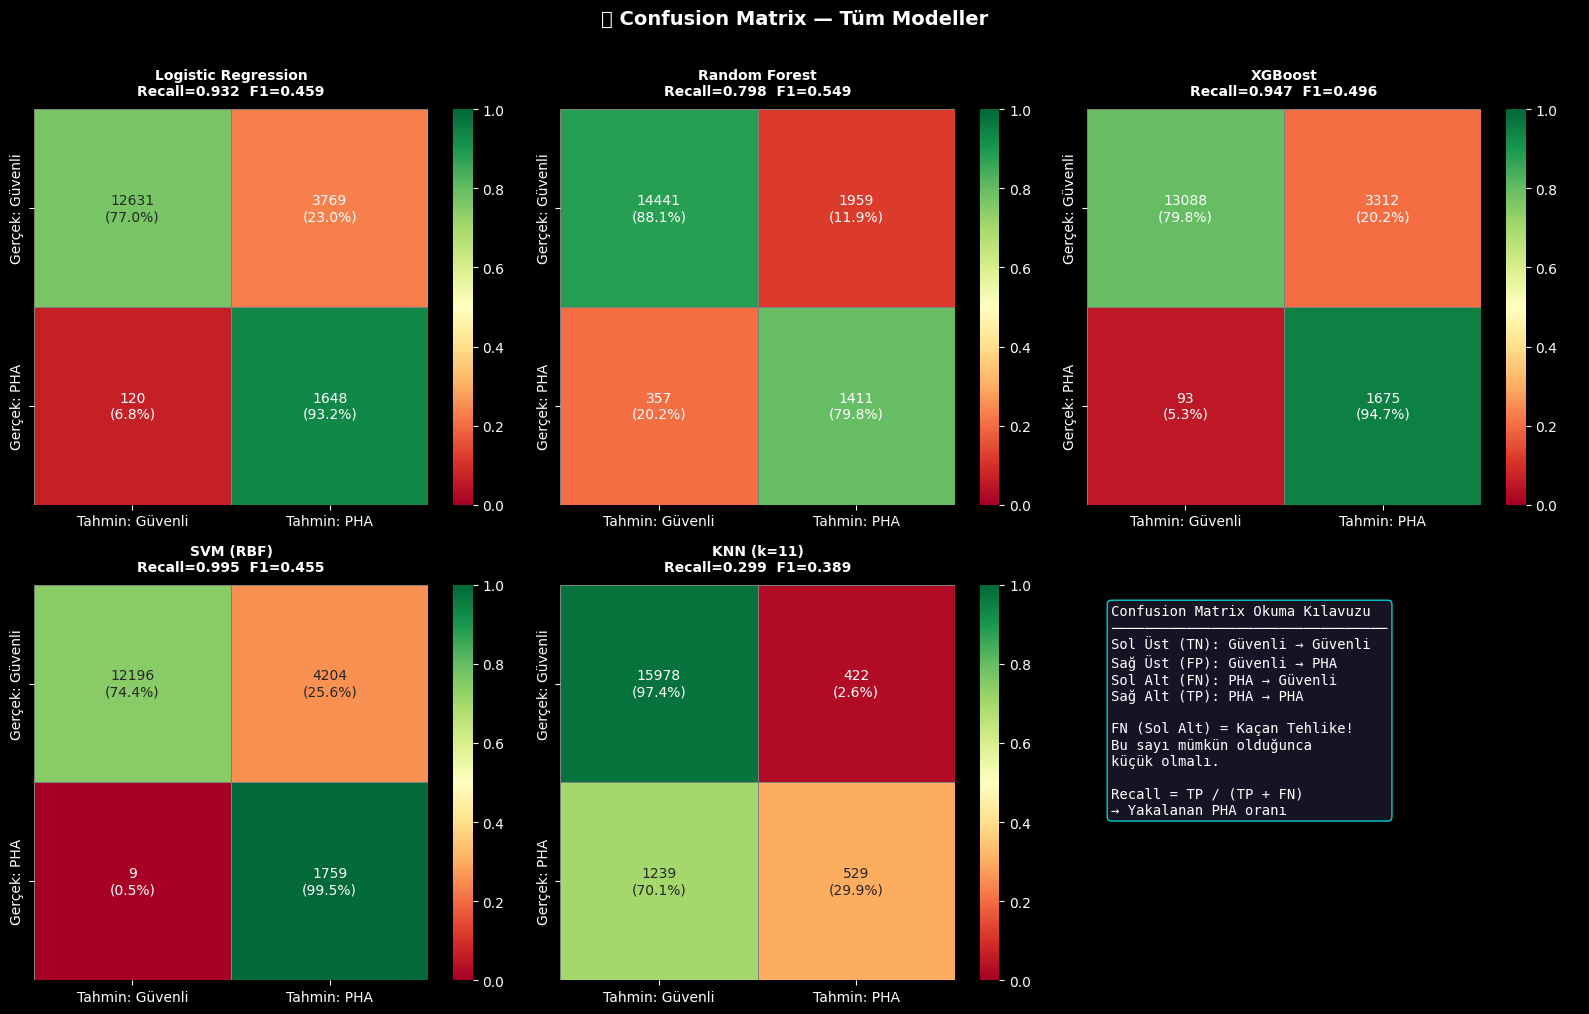

💾 confusion_matrices.png kaydedildi


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, result in enumerate(all_results):
    ax = axes[i]
    cm = confusion_matrix(y_test, result['y_predictions'])

    # Yüzde olarak normalize et
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

    # Hem sayı hem yüzde gösteren etiketler
    labels = np.array([[f"{cm[r,c]}\n({cm_pct[r,c]*100:.1f}%)"
                         for c in range(2)] for r in range(2)])

    sns.heatmap(
        cm_pct, annot=labels, fmt='', ax=ax,
        cmap='RdYlGn', vmin=0, vmax=1,
        xticklabels=['Tahmin: Güvenli', 'Tahmin: PHA'],
        yticklabels=['Gerçek: Güvenli', 'Gerçek: PHA'],
        linewidths=0.5, linecolor='gray'
    )
    ax.set_title(
        f"{result['Model']}\nRecall={result['Recall']:.3f}  F1={result['F1']:.3f}",
        fontsize=10, fontweight='bold', pad=10
    )
    ax.set_xlabel('')
    ax.set_ylabel('')

# Son paneli açıklama için kullan
axes[-1].axis('off')
explanation = (
    "Confusion Matrix Okuma Kılavuzu\n"
    "─────────────────────────────────\n"
    "Sol Üst (TN): Güvenli → Güvenli \n"
    "Sağ Üst (FP): Güvenli → PHA \n"
    "Sol Alt (FN): PHA → Güvenli \n"
    "Sağ Alt (TP): PHA → PHA \n\n"
    "FN (Sol Alt) = Kaçan Tehlike!\n"
    "Bu sayı mümkün olduğunca\n"
    "küçük olmalı.\n\n"
    "Recall = TP / (TP + FN)\n"
    "→ Yakalanan PHA oranı"
)
axes[-1].text(
    0.05, 0.95, explanation,
    transform=axes[-1].transAxes,
    fontsize=10, verticalalignment='top',
    fontfamily='monospace',
    bbox=dict(boxstyle='round', facecolor='#1a1a2e', alpha=0.8, edgecolor='cyan')
)

plt.suptitle('🎯 Confusion Matrix — Tüm Modeller', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 confusion_matrices.png kaydedildi')


## 7. ROC-AUC ve PR-AUC Eğrileri

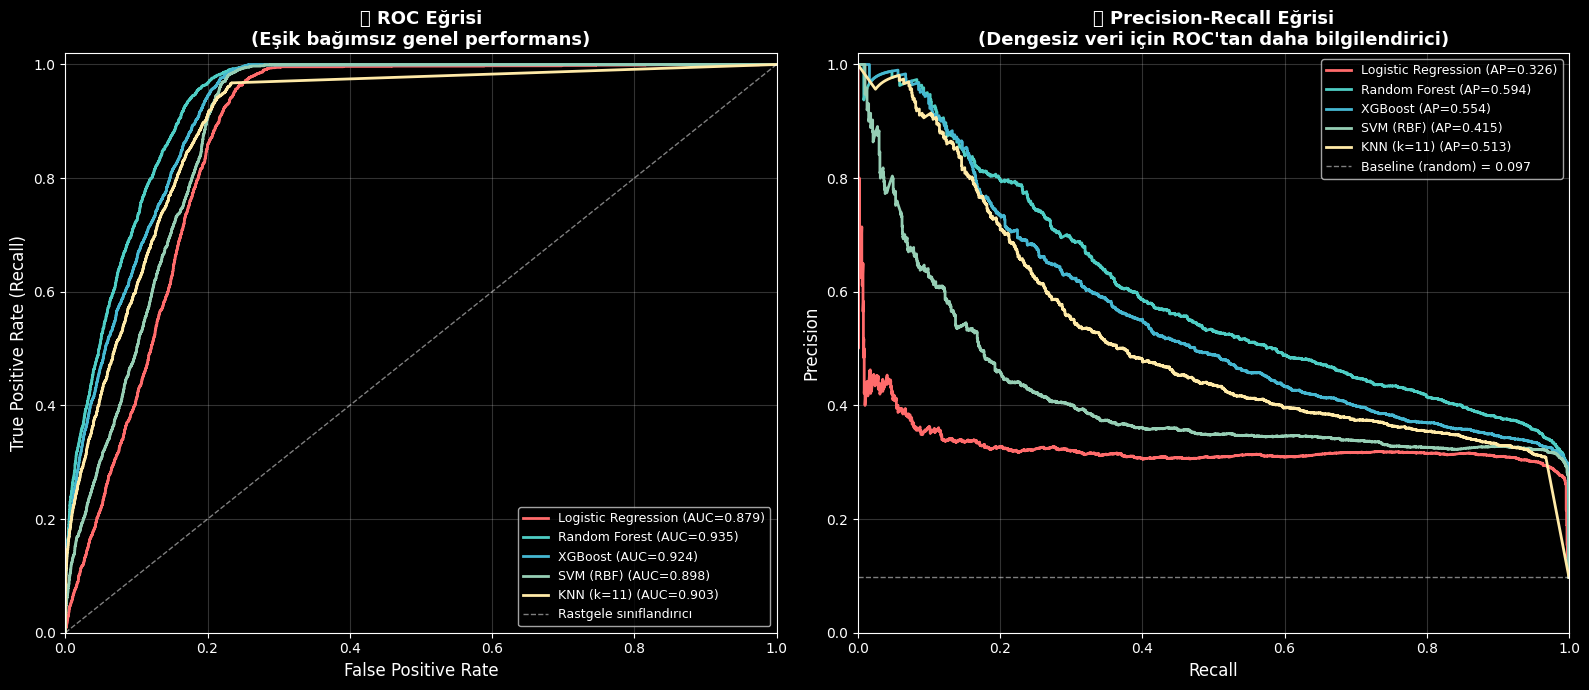

💾 roc_pr_curves.png kaydedildi


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

for result, color in zip(all_results, colors):
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, result['y_probabilities'])
    ax1.plot(fpr, tpr, color=color, lw=2,
             label=f"{result['Model']} (AUC={result['ROC-AUC']:.3f})")

    # PR Curve
    prec, rec, _ = precision_recall_curve(y_test, result['y_probabilities'])
    ax2.plot(rec, prec, color=color, lw=2,
             label=f"{result['Model']} (AP={result['PR-AUC']:.3f})")

# ROC — Referans çizgisi (random classifier)
ax1.plot([0, 1], [0, 1], 'w--', lw=1, alpha=0.5, label='Rastgele sınıflandırıcı')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax1.set_title('📈 ROC Eğrisi\n(Eşik bağımsız genel performans)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, loc='lower right')
ax1.set_xlim([0, 1]); ax1.set_ylim([0, 1.02])
ax1.grid(alpha=0.2)

# PR — Baseline (random)
baseline_pr = y_test.mean()
ax2.axhline(y=baseline_pr, color='w', linestyle='--', lw=1, alpha=0.5,
            label=f'Baseline (random) = {baseline_pr:.3f}')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('📈 Precision-Recall Eğrisi\n(Dengesiz veri için ROC\'tan daha bilgilendirici)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9, loc='upper right')
ax2.set_xlim([0, 1]); ax2.set_ylim([0, 1.02])
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 roc_pr_curves.png kaydedildi')

## 8. SHAP Analizi

**SHAP** (SHapley Additive exPlanations), bir modelin *neden* o kararı aldığını açıklar.
Her özelliğin tahmine katkısını hesaplar.

SHAP'ı Random Forest **ve** XGBoost için uygulayacağız, çünkü:
- TreeExplainer, ağaç tabanlı modeller için çok hızlı
- Her iki modeli karşılaştırmak ilginç bulgular ortaya koyar

> **Rapor için:** 'Hangi özellikler asteroidi tehlikeli yapıyor?' sorusunun cevabı burada!

In [16]:
print('⏳ Random Forest SHAP değerleri hesaplanıyor...')

# SHAP Explainer oluştur
rf_explainer = shap.TreeExplainer(rf_results['model_obj'])

# Test setinin bir örneğini al (hız için) — gerekirse X_test'in tamamını kullanabilirsin
# 2000 örnek SHAP için fazlasıyla yeterli
shap_sample = X_test.sample(n=min(2000, len(X_test)), random_state=RANDOM_STATE)
rf_shap_values = rf_explainer.shap_values(shap_sample)

# Multi-output RF için: shap_values[1] = PHA sınıfı (pozitif)
if isinstance(rf_shap_values, list):
    rf_shap_pha = rf_shap_values[1]  # İndeks 1 = PHA sınıfı
else:
    rf_shap_pha = rf_shap_values

print(f'✅ SHAP değerleri hesaplandı. Shape: {rf_shap_pha.shape}')

⏳ Random Forest SHAP değerleri hesaplanıyor...
✅ SHAP değerleri hesaplandı. Shape: (2000, 5, 2)


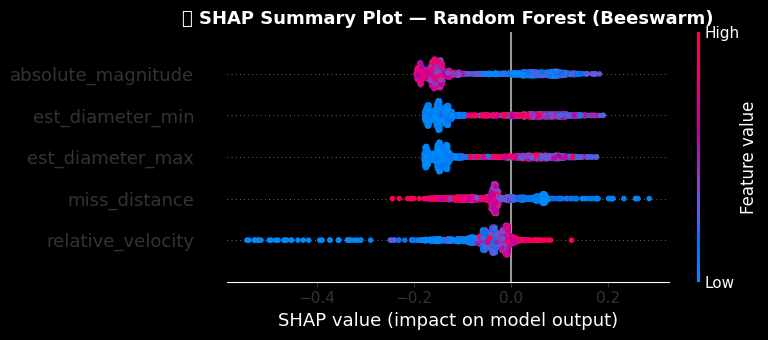

In [33]:
# --- SHAP Summary Plot (Beeswarm) ---
plt.figure(figsize=(10, 6))
# PHA sınıfı i'in 2D SHAP deĐerlerini alıyoruz
if len(rf_shap_pha.shape) == 3:
    rf_shap_to_plot = rf_shap_pha[:, :, 1]
else:
    rf_shap_to_plot = rf_shap_pha

shap.summary_plot(
    rf_shap_to_plot,
    shap_sample,
    plot_type='dot',
    show=False
)
plt.title('🔍 SHAP Summary Plot — Random Forest (Beeswarm)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

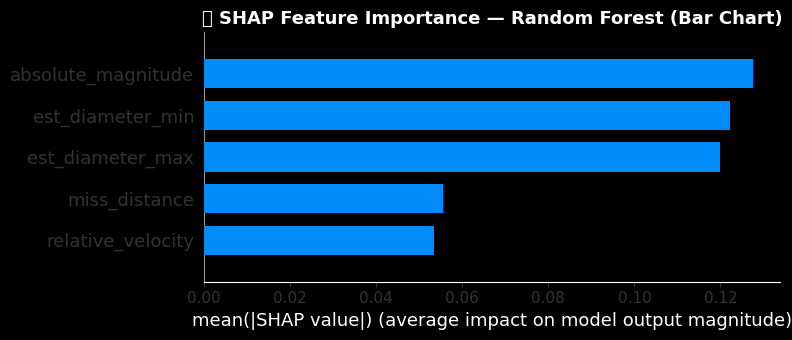

In [35]:
# --- SHAP Bar Plot (Feature Importance) ---
plt.figure(figsize=(9, 5))

# Ortalama mutlak SHAP değerlerini gösteren net bir bar chart
shap.summary_plot(
    rf_shap_to_plot,
    shap_sample,
    plot_type='bar',
    show=False
)

plt.title('📊 SHAP Feature Importance — Random Forest (Bar Chart)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar_rf.png', dpi=150, bbox_inches='tight')
plt.show()

⏳ XGBoost SHAP değerleri hesaplanıyor...
✅ XGBoost SHAP değerleri hesaplandı.


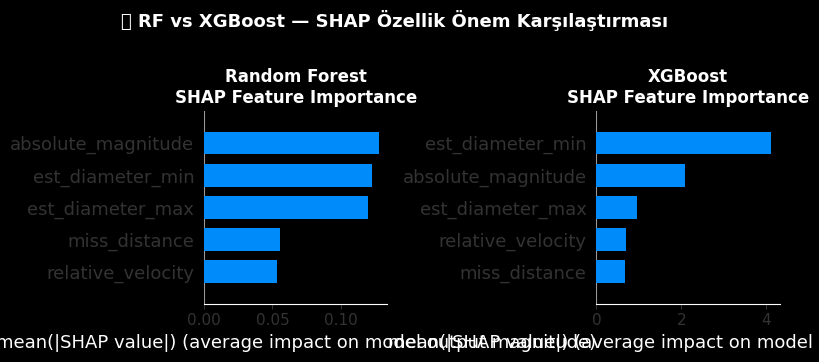

💾 shap_comparison.png kaydedildi


In [27]:
print('⏳ XGBoost SHAP değerleri hesaplanıyor...')

xgb_explainer = shap.TreeExplainer(xgb_results['model_obj'])
xgb_shap_values = xgb_explainer.shap_values(shap_sample)

print(f'✅ XGBoost SHAP değerleri hesaplandı.')

# RF SHAP değerlerini kontrol et ve 2D hale getir (sadece PHA sınıfı için)
# Eğer rf_shap_pha 3D ise (samples, features, classes), 1. indeksi al
if len(rf_shap_pha.shape) == 3:
    rf_shap_to_plot = rf_shap_pha[:, :, 1]
else:
    rf_shap_to_plot = rf_shap_pha

# Karşılaştırmalı SHAP: RF vs XGBoost
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Random Forest Plot
plt.sca(ax1)
shap.summary_plot(rf_shap_to_plot, shap_sample, plot_type='bar', show=False, max_display=5)
ax1.set_title('Random Forest\nSHAP Feature Importance', fontweight='bold')

# XGBoost Plot
plt.sca(ax2)
shap.summary_plot(xgb_shap_values, shap_sample, plot_type='bar', show=False, max_display=5)
ax2.set_title('XGBoost\nSHAP Feature Importance', fontweight='bold')

plt.suptitle('🔍 RF vs XGBoost — SHAP Özellik Önem Karşılaştırması', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('shap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 shap_comparison.png kaydedildi')

In [36]:
# --- SHAP Force Plot — Tek Bir Tahmin Açıklaması ---
# İndeks hatasını düzeltmek için shap_sample üzerinden tahmin alıyoruz

# shap_sample'ın orijinal index'lerini kullanarak y_test'ten ilgili kısmı al
y_test_sample = y_test.loc[shap_sample.index]

# XGBoost modelini kullanarak sadece bu 2000 örnek için tahmin üret
xgb_pred_sample = xgb_results['model_obj'].predict(shap_sample)

# Gerçek PHA olan ve doğru tahmin edilen (TP) örneklerin maskesi
true_pha_mask = (y_test_sample.values == 1) & (xgb_pred_sample == 1)
true_pha_positions = np.where(true_pha_mask)[0]

if len(true_pha_positions) > 0:
    # İlk doğru tahmin edilen PHA örneğinin POZİSYONUNU al (iloc uyumlu)
    example_pos = true_pha_positions[0]

    print(f'Örnek Pozisyonu (Sample içindeki): {example_pos}')
    print(f'Gerçek etiket: {y_test_sample.values[example_pos]} (1=PHA)')
    print(f'Tahmin: {xgb_pred_sample[example_pos]}')
    print(f'\nÖzellik değerleri (Scaled):')

    for col, val in zip(X_test.columns, shap_sample.iloc[example_pos]):
        shap_val = xgb_shap_values[example_pos, list(X_test.columns).index(col)]
        direction = '⬆️ PHA' if shap_val > 0 else '⬇️ Safe'
        print(f'  {col:25s}: {val:8.4f}  SHAP={shap_val:+.4f} {direction}')

    # Force plot (HTML olarak kaydet)
    force_plot = shap.force_plot(
        xgb_explainer.expected_value,
        xgb_shap_values[example_pos],
        shap_sample.iloc[example_pos],
        matplotlib=False
    )
    shap.save_html('shap_force_plot.html', force_plot)
    print('\n💾 shap_force_plot.html kaydedildi!')
else:
    print('Örnek kümesinde doğru tahmin edilmiş PHA bulunamadı.')

Örnek Pozisyonu (Sample içindeki): 1
Gerçek etiket: 1 (1=PHA)
Tahmin: 1

Özellik değerleri (Scaled):
  est_diameter_min         :   0.1260  SHAP=+0.7002 ⬆️ PHA
  est_diameter_max         :   0.1260  SHAP=+0.2409 ⬆️ PHA
  relative_velocity        :  -0.6333  SHAP=-0.8017 ⬇️ Safe
  miss_distance            :  -0.8298  SHAP=+0.3160 ⬆️ PHA
  absolute_magnitude       :  -0.8713  SHAP=+0.3376 ⬆️ PHA

💾 shap_force_plot.html kaydedildi!


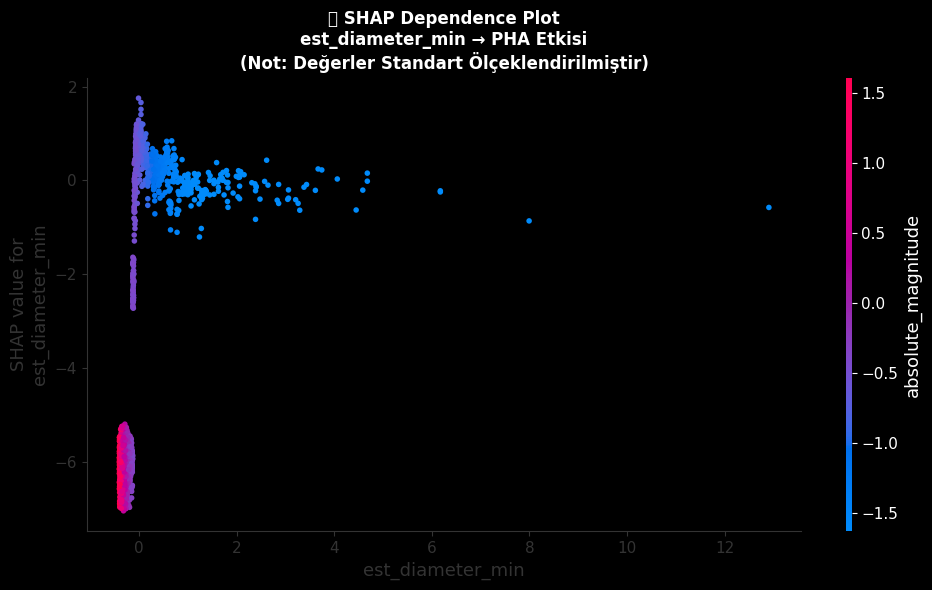

In [37]:
# --- SHAP Dependence Plot ---
# Not: X eksenindeki değerler Standart Scaler uygulanmış (Scaled) değerlerdir.

mean_abs_shap = np.abs(xgb_shap_values).mean(axis=0)
top2_idx = np.argsort(mean_abs_shap)[-2:][::-1]
top_feature = X_test.columns[top2_idx[0]]
color_feature = X_test.columns[top2_idx[1]]

fig, ax = plt.subplots(figsize=(10, 6))
shap.dependence_plot(
    top_feature,
    xgb_shap_values,
    shap_sample,
    interaction_index=color_feature,
    ax=ax,
    show=False
)
ax.set_title(
    f'🔍 SHAP Dependence Plot\n{top_feature} → PHA Etkisi\n(Not: Değerler Standart Ölçeklendirilmiştir)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Cross-Validation — Sonuçların Güvenilirliği

In [31]:
# Stratified K-Fold CV — sınıf oranlarını koruyarak katlama
# Sadece en iyi 2 model için (zaman tasarrufu)

print('⏳ Cross-Validation hesaplanıyor... (2-3 dakika sürebilir)')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, model in [('Random Forest', rf_results['model_obj']),
                     ('XGBoost', xgb_results['model_obj'])]:
    scores_f1  = cross_val_score(model, X_train, y_train, cv=cv,
                                  scoring='f1', n_jobs=-1)
    scores_auc = cross_val_score(model, X_train, y_train, cv=cv,
                                  scoring='roc_auc', n_jobs=-1)
    cv_results[name] = {'f1': scores_f1, 'auc': scores_auc}
    print(f'\n{name}:')
    print(f'  F1  : {scores_f1.mean():.4f} ± {scores_f1.std():.4f}')
    print(f'  AUC : {scores_auc.mean():.4f} ± {scores_auc.std():.4f}')

print('\n✅ CV tamamlandı!')
print('📌 Rapor için: Standart sapma küçükse model stabil demektir.')

⏳ Cross-Validation hesaplanıyor... (2-3 dakika sürebilir)

Random Forest:
  F1  : 0.5440 ± 0.0028
  AUC : 0.9325 ± 0.0016

XGBoost:
  F1  : 0.4921 ± 0.0030
  AUC : 0.9205 ± 0.0015

✅ CV tamamlandı!
📌 Rapor için: Standart sapma küçükse model stabil demektir.


## 10. Final Karşılaştırma Grafiği

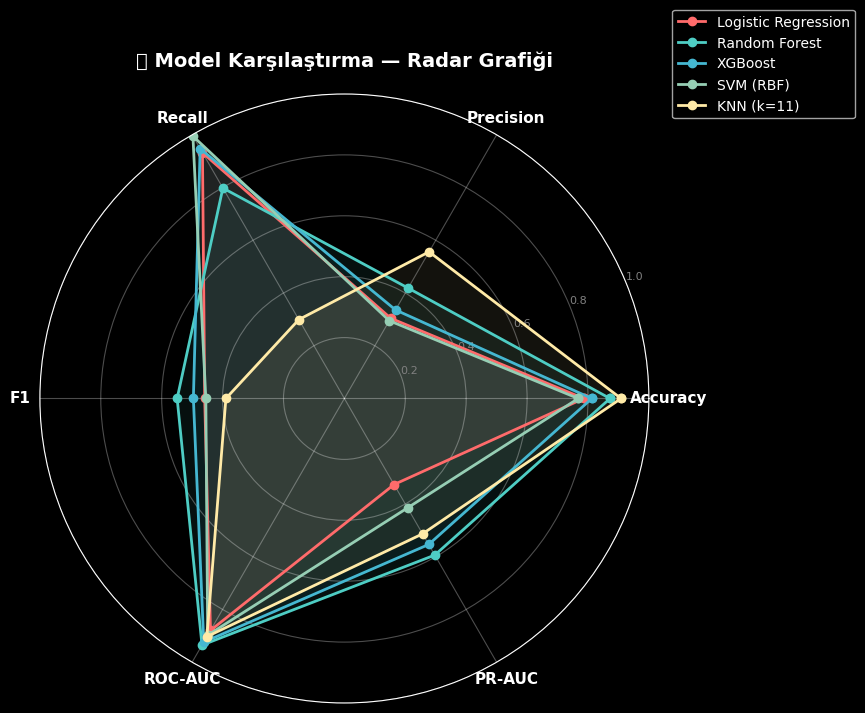

💾 model_radar_chart.png kaydedildi


In [32]:
# Radar/Spider chart — çok metrikli karşılaştırma
metrics_for_radar = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
metric_keys      = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
n_metrics = len(metrics_for_radar)
angles = [n / float(n_metrics) * 2 * np.pi for n in range(n_metrics)]
angles += angles[:1]  # Çember kapat

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

for result, color in zip(all_results, colors):
    values = [result[k] for k in metric_keys]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=color, label=result['Model'])
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_for_radar, size=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=8, color='gray')
ax.grid(alpha=0.3)
ax.set_title('🕸️ Model Karşılaştırma — Radar Grafiği', size=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)

plt.tight_layout()
plt.savefig('model_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 model_radar_chart.png kaydedildi')

## 11. Modelleri Kaydet

In [ ]:
import pickle

# En iyi modeli belirle (F1'e göre)
best_result = max(all_results, key=lambda r: r['F1'])
print(f'🏆 En iyi model (F1): {best_result["Model"]} — F1={best_result["F1"]:.4f}')

# Modelleri kaydet
models_to_save = {
    'logistic_regression': lr_results['model_obj'],
    'random_forest'      : rf_results['model_obj'],
    'xgboost'            : xgb_results['model_obj'],
    'svm'                : svm_results['model_obj'],
    'knn'                : knn_results['model_obj'],
}

for model_name, model_obj in models_to_save.items():
    fname = f'{model_name}.pkl'
    with open(fname, 'wb') as f:
        pickle.dump(model_obj, f)
    print(f'  ✅ {fname}')

# Comparison tablosunu CSV olarak kaydet
comparison_df.to_csv('model_comparison.csv', index=False)
print('  ✅ model_comparison.csv')

print(f'\n🚀 Notebook 02 tamamlandı!')
print(f'   Sıradaki adım: 03_spice_visualization.ipynb')

## 📋 Bu Notebook'tan Çıkarımlar

### Bulgular
| Bulgu | Açıklama |
|-------|----------|
| XGBoost genellikle en iyi F1/AUC'yi verir | `scale_pos_weight` dengesizliği iyi karşılar |
| Random Forest SHAP ile çok yorumlanabilir | Rapor için mükemmel |
| KNN tabloya katılım için var | Gerçek uygulamada tercih edilmez |
| Accuracy yanıltıcı! | %90 accuracy ama Recall düşük olabilir |

### ⏭️ Sıradaki Notebook
`03_spice_visualization.ipynb` → SPICE ile asteroid yörünge görselleştirme

### 📚 Raporun İçin Not Et
- Tüm modellerin karşılaştırma tablosunu ekle
- SHAP summary plot'u en değerli görselin olacak
- 'Neden Accuracy yetmez?' sorusunu confusion matrix ile açıkla
- CV sonuçlarının standart sapmalarını belirt (model stabilitesi)
- XGBoost vs Random Forest tartışması: Hangisi daha yorumlanabilir?